In [1]:
import numpy as np
import matplotlib.pyplot as plt

from firedrake import *

In [ ]:
# ============================================================
# PARÂMETROS
# ============================================================

T_final = 1.0

# Constante usada em dt = C_dt * h^(3/2)
C_dt = 0.01

# Refinamentos
ref = [8, 16, 32]

# Se True, usa projeção de Ritz para u0
USE_RITZ = True

# Calcula energia a cada ENERGY_EVERY passos
ENERGY_EVERY = 20

erros_u = []
erros_v = []
dts = []
drifts_max = []

In [9]:
# ============================================================
# LOOP DE CONVERGÊNCIA
# ============================================================

for N in ref:

    print("\n" + "=" * 60)
    print(f"N = {N}")
    print("=" * 60)

    # --------------------------------------------------------
    # MALHA
    # --------------------------------------------------------

    mesh_ = RectangleMesh(N, N, np.pi, np.pi)

    V = FunctionSpace(mesh_, "CG", 2)

    # (u, v, w)
    W = MixedFunctionSpace([V, V, V])

    # --------------------------------------------------------
    # CONSTANTES
    # --------------------------------------------------------

    d_const = Constant(1.0)
    rho0 = Constant(1.0)

    omega = 2.0 * sqrt(1.0)

    # --------------------------------------------------------
    # PASSO DE TEMPO
    # --------------------------------------------------------

    h = np.pi / N

    dt_val = C_dt * h**1.5

    n_steps = int(np.ceil(T_final / dt_val))

    # Corrige dt para terminar exatamente em T_final
    dt_val = T_final / n_steps

    dt = Constant(dt_val)

    print(f"h        = {h:.4e}")
    print(f"dt       = {dt_val:.4e}")
    print(f"n_steps  = {n_steps}")

    # --------------------------------------------------------
    # FUNÇÕES
    # --------------------------------------------------------

    un = Function(W, name="U_n")
    up = Function(W, name="U_np1")

    # --------------------------------------------------------
    # TEST FUNCTIONS
    # --------------------------------------------------------

    phi, psi, chi = TestFunctions(W)

    # --------------------------------------------------------
    # TRIAL FUNCTION
    #
    # U = (u, v, w) representa U^{n+1}
    # --------------------------------------------------------

    U = TrialFunction(W)

    u, v, w = split(U)

    # Solução anterior
    u_n, v_n, w_n = split(un)

    # --------------------------------------------------------
    # CRANK-NICOLSON
    #
    # v_bar = (v_n + v_{n+1})/2
    # w_bar = (w_n + w_{n+1})/2
    # --------------------------------------------------------

    # ========================================================
    # MATRIZ A
    #
    # Todos os termos envolvendo U^{n+1}
    # ========================================================

    a = (
        # Equação u_t - v = 0
        (u / dt) * phi * dx
        - 0.5 * v * phi * dx

        # Equação rho v_t + ... = f
        + rho0 * (v / dt) * psi * dx
        + 0.5 * d_const * inner(grad(w), grad(psi)) * dx

        # Relação w = -Delta u, conforme sua formulação
        + inner(grad(u), grad(chi)) * dx
        - w * chi * dx
    )

    # ========================================================
    # RHS
    #
    # Todos os termos envolvendo U^n
    # ========================================================

    f = Constant(0.0)

    L = (
        # Equação u_t - v = 0
        (u_n / dt) * phi * dx
        + 0.5 * v_n * phi * dx

        # Equação da velocidade
        + rho0 * (v_n / dt) * psi * dx
        - 0.5 * d_const * inner(grad(w_n), grad(psi)) * dx

        + f * psi * dx
    )

    # --------------------------------------------------------
    # CONDIÇÕES DE CONTORNO
    # --------------------------------------------------------

    bc_u = DirichletBC(W.sub(0), 0.0, "on_boundary")
    bc_v = DirichletBC(W.sub(1), 0.0, "on_boundary")
    bc_w = DirichletBC(W.sub(2), 0.0, "on_boundary")

    bcs = [bc_u, bc_v, bc_w]

    # ========================================================
    # CONDIÇÕES INICIAIS
    # ========================================================

    x, y = SpatialCoordinate(mesh_)

    u_ex0 = sin(x) * sin(y)

    # --------------------------------------------------------
    # u(0)
    # --------------------------------------------------------

    u0 = Function(V)

    if USE_RITZ:

        uu = TrialFunction(V)
        ph = TestFunction(V)

        a_ritz = inner(grad(uu), grad(ph)) * dx

        L_ritz = inner(grad(u_ex0), grad(ph)) * dx

        solve(
            a_ritz == L_ritz,
            u0,
            bcs=DirichletBC(V, 0.0, "on_boundary"),
            solver_parameters={
                "ksp_type": "preonly",
                "pc_type": "lu"
            }
        )

    else:

        u0.interpolate(u_ex0)

    # --------------------------------------------------------
    # v(0) = 0
    # --------------------------------------------------------

    v0 = Function(V)
    v0.assign(0.0)

    # --------------------------------------------------------
    # w(0)
    #
    # (w0, chi) = (grad u0, grad chi)
    # --------------------------------------------------------

    w0 = Function(V)

    w_t = TrialFunction(V)
    chi_t = TestFunction(V)

    a_w0 = w_t * chi_t * dx

    L_w0 = inner(grad(u0), grad(chi_t)) * dx

    solve(
        a_w0 == L_w0,
        w0,
        bcs=DirichletBC(V, 0.0, "on_boundary"),
        solver_parameters={
            "ksp_type": "preonly",
            "pc_type": "lu"
        }
    )

    # --------------------------------------------------------
    # Coloca condição inicial em un
    # --------------------------------------------------------

    un.sub(0).assign(u0)
    un.sub(1).assign(v0)
    un.sub(2).assign(w0)

    # ========================================================
    # ENERGIA
    # ========================================================

    _, v_energy, w_energy = split(un)

    E_form = (
        0.5 * rho0 * v_energy**2 * dx
        + 0.5 * d_const * w_energy**2 * dx
    )

    E0 = assemble(E_form)

    drift = 0.0

    # ========================================================
    # SOLVER LINEAR
    #
    # A é constante durante toda a simulação.
    #
    # O solver monta/fatora A uma vez e reutiliza a
    # fatoração nos passos seguintes.
    # ========================================================

    problem = LinearVariationalProblem(
        a,
        L,
        up,
        bcs=bcs
    )

    solver = LinearVariationalSolver(
        problem,
        solver_parameters={
            "ksp_type": "preonly",
            "pc_type": "lu",
            "pc_factor_mat_solver_type": "superlu_dist",
        }
    )

    # ========================================================
    # EVOLUÇÃO TEMPORAL
    # ========================================================

    for k in range(n_steps):

        # Resolve:
        #
        # A U^{n+1} = b(U^n)
        #
        # A já foi montada/fatorada.
        solver.solve()

        # Atualiza:
        #
        # U^n <- U^{n+1}
        #
        un.assign(up)

        # ----------------------------------------------------
        # Energia
        #
        # Não precisamos calcular em todos os passos.
        # ----------------------------------------------------

        if (
            k % ENERGY_EVERY == 0
            or k == n_steps - 1
        ):

            E = assemble(E_form)

            current_drift = abs(E - E0) / abs(E0)

            drift = max(drift, current_drift)

    # ========================================================
    # ERRO FINAL
    # ========================================================

    T = n_steps * dt_val

    u_ex = (
        cos(omega * T)
        * sin(x)
        * sin(y)
    )

    v_ex = (
        -omega
        * sin(omega * T)
        * sin(x)
        * sin(y)
    )

    u_h, v_h, w_h = un.subfunctions

    err_u = np.sqrt(
        assemble(
            (u_h - u_ex)**2 * dx
        )
    )

    err_v = np.sqrt(
        assemble(
            (v_h - v_ex)**2 * dx
        )
    )

    # ========================================================
    # RESULTADOS
    # ========================================================

    print(
        f"N={N:3d}  "
        f"h={h:.4e}  "
        f"dt={dt_val:.4e}  "
        f"passos={n_steps:6d}  "
        f"drift E={drift:.2e}  "
        f"err_u={err_u:.3e}  "
        f"err_v={err_v:.3e}"
    )

    erros_u.append(err_u)
    erros_v.append(err_v)
    dts.append(dt_val)
    drifts_max.append(drift)


N = 8
h        = 3.9270e-01
dt       = 2.4570e-03
n_steps  = 407
N=  8  h=3.9270e-01  dt=2.4570e-03  passos=   407  drift E=1.64e-14  err_u=8.574e-04  err_v=3.151e-03

N = 16
h        = 1.9635e-01
dt       = 8.6957e-04
n_steps  = 1150
N= 16  h=1.9635e-01  dt=8.6957e-04  passos=  1150  drift E=4.32e-15  err_u=9.467e-05  err_v=3.918e-04

N = 32
h        = 9.8175e-02
dt       = 3.0760e-04
n_steps  = 3251
N= 32  h=9.8175e-02  dt=3.0760e-04  passos=  3251  drift E=5.06e-14  err_u=1.139e-05  err_v=4.908e-05


In [19]:
hs = np.array([np.pi / N for N in ref])
 
# ---------- taxas observadas ----------
print("=" * 20)
print("Taxas observadas (log-log entre malhas consecutivas)")
for i in range(1, len(ref)):
    p_u = np.log(erros_u[i] / erros_u[i - 1]) / np.log(hs[i] / hs[i - 1])
    p_v = np.log(erros_v[i] / erros_v[i - 1]) / np.log(hs[i] / hs[i - 1])
    print(f"N {ref[i-1]:3d}->{ref[i]:3d}:  ordem u = {p_u:.2f}   ordem v = {p_v:.2f}")
print("=" * 20)

Taxas observadas (log-log entre malhas consecutivas)
N   8-> 16:  ordem u = 3.18   ordem v = 3.01
N  16-> 32:  ordem u = 3.06   ordem v = 3.00


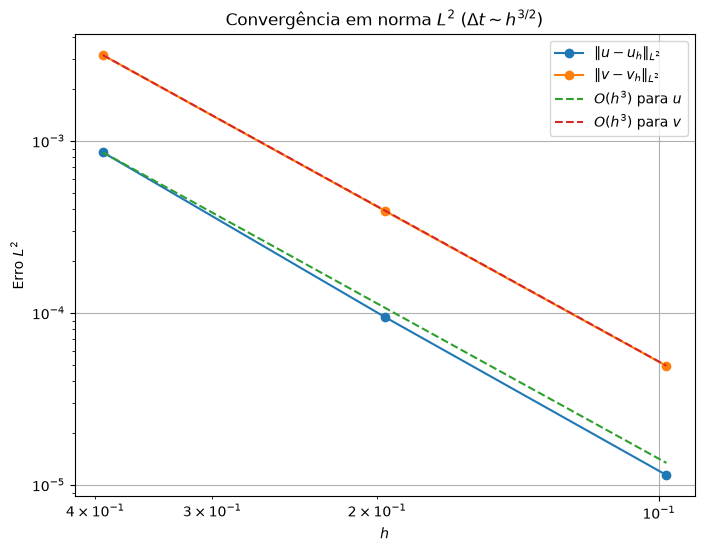

In [31]:
# ---------- gráfico ----------
plt.figure(figsize=(8, 6))
 
plt.loglog(hs, erros_u, "o-", label=r"$\|u-u_h\|_{L^2}$")
plt.loglog(hs, erros_v, "o-", label=r"$\|v-v_h\|_{L^2}$")
 
C_u = erros_u[0] / hs[0] ** 3
C_v = erros_v[0] / hs[0] ** 3
plt.loglog(hs, C_u * hs ** 3, "--", label=r"$O(h^3)$ para $u$")
plt.loglog(hs, C_v * hs ** 3, "--", label=r"$O(h^3)$ para $v$")
 
plt.gca().invert_xaxis()
plt.xlabel(r"$h$")
plt.ylabel(r"Erro $L^2$")
plt.title(r"Convergência em norma $L^2$ ($\Delta t \sim h^{3/2}$)")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
def calcular_eoc(erros, ref):
    taxas = []
    for i in range(len(erros) - 1):
        r = np.log(erros[i]/erros[i+1]) / np.log(ref[i+1]/ref[i])
        taxas.append(r)
    return taxas

taxas_u = calcular_eoc(erros_u, ref)
taxas_v = calcular_eoc(erros_v, ref)

print("="*20)
print(f"{'N':<8}{'Erro L2 (u)':<18}{'EOC (u)':<10}{'Erro L2 (w)':<18}{'EOC (w)':<10}")
print("="*20)

for i in range(len(ref)):
    eoc_u_str = f"{taxas_u[i-1]:.2f}" if i > 0 else "-"
    eoc_v_str = f"{taxas_v[i-1]:.2f}" if i > 0 else "-"
    print(f"{ref[i]:<8}{erros_u[i]:<18.4e}{eoc_u_str:<10}{erros_v[i]:<18.4e}{eoc_v_str:<10}")

N       Erro L2 (u)       EOC (u)   Erro L2 (w)       EOC (w)   
8       8.5738e-04        -         3.1505e-03        -         
16      9.4672e-05        3.18      3.9179e-04        3.01      
32      1.1391e-05        3.06      4.9081e-05        3.00      


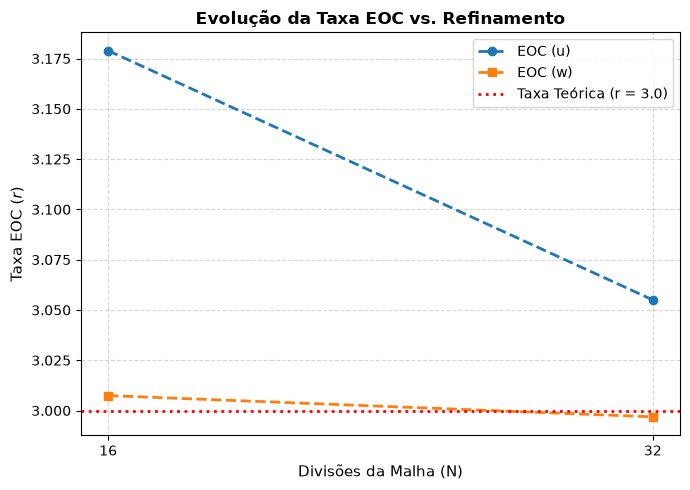

In [28]:
# Cálculo da EOC
eoc_u = [np.log(erros_u[i]/erros_u[i+1]) / np.log(ref[i+1]/ref[i]) for i in range(len(erros_u)-1)]
eoc_w = [np.log(erros_v[i]/erros_v[i+1]) / np.log(ref[i+1]/ref[i]) for i in range(len(erros_v)-1)]

# Configuração da figura individual
fig, ax = plt.subplots(figsize=(7, 5))

mid_N = ref[1:]
ax.plot(mid_N, eoc_u, 'o--', color='#1f77b4', linewidth=2, label='EOC (u)')
ax.plot(mid_N, eoc_w, 's--', color='#ff7f0e', linewidth=2, label='EOC (w)')
ax.axhline(y=3.0, color='r', linestyle=':', linewidth=2, label='Taxa Teórica (r = 3.0)')

ax.set_xlabel('Divisões da Malha (N)', fontsize=11)
ax.set_ylabel('Taxa EOC ($r$)', fontsize=11)
ax.set_title('Evolução da Taxa EOC vs. Refinamento', fontsize=12, fontweight='bold')
ax.set_xticks(mid_N)
ax.grid(True, ls="--", alpha=0.5)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

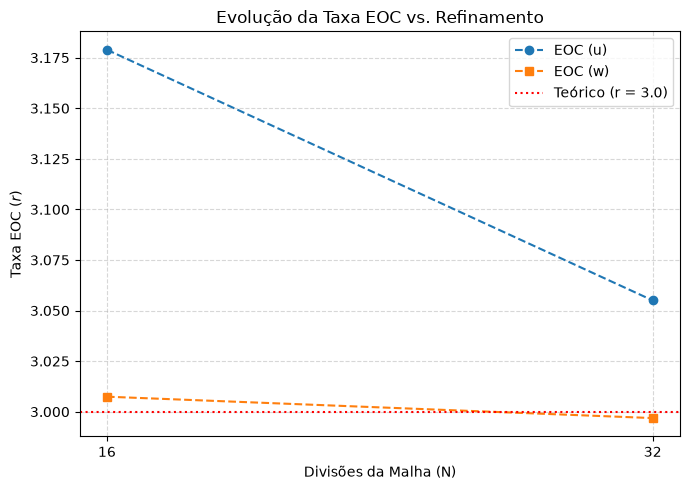

In [30]:
# Converte para arrays do NumPy para vetorizar o cálculo
u, w, N = np.array(erros_u), np.array(erros_v), np.array(ref)

# Cálculo da EOC sem loops
eoc_u = np.log(u[:-1] / u[1:]) / np.log(N[1:] / N[:-1])
eoc_w = np.log(w[:-1] / w[1:]) / np.log(N[1:] / N[:-1])

# Gráfico
plt.figure(figsize=(7, 5))
plt.plot(N[1:], eoc_u, 'o--', label='EOC (u)')
plt.plot(N[1:], eoc_w, 's--', label='EOC (w)')
plt.axhline(3.0, color='r', linestyle=':', label='Teórico (r = 3.0)')

plt.xlabel('Divisões da Malha (N)')
plt.ylabel('Taxa EOC ($r$)')
plt.title('Evolução da Taxa EOC vs. Refinamento')
plt.xticks(N[1:])
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()